<a href="https://colab.research.google.com/github/Destinywaya9/QCC-Bench/blob/main/Unaddressed%20and%20Resolved%20Fatalism%20of%20Pauli-Z.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit matplotlib

Now that the necessary libraries are installed, I'll run the original code.

In [ ]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.1 MB/s eta 0:00:00


In [ ]:
# --- Required Libraries ---
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error, thermal_relaxation_error
from qiskit.visualization import plot_histogram
# from qiskit.compiler import assemble # assemble is no longer needed


# --- Step 1: Define EchoLift Tensor P2 Kernel ---
def build_kernel():
    qc = QuantumCircuit(3)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 1)
    qc.cx(1, 0) # Corrected indentation
    qc.h(0)
    qc.barrier()
    qc.delay(200, 0, 'ns')
    qc.delay(200, 1, 'ns')
    qc.delay(200, 2, 'ns')
    qc.measure_all()
    return qc

# --- Step 2: Build Compound Radiation Noise Model ---
def build_noise_model():
    noise_model = NoiseModel()

    # SEP burst (Pauli)
    # sep_error = pauli_error([('X', 0.25), ('Y', 0.25), ('Z', 0.25), ('I', 0.25)]) # This is a 1-qubit error
    sep_error_1q = pauli_error([('X', 0.25), ('Y', 0.25), ('Z', 0.25), ('I', 0.25)])
    sep_error = sep_error_1q.tensor(sep_error_1q) # Create a 2-qubit error by tensoring
    noise_model.add_all_qubit_quantum_error(sep_error, ['cx'])


    # Full depolarizing (GCR hit)
    catastrophic_depol = depolarizing_error(1.0, 2)
    noise_model.add_all_qubit_quantum_error(catastrophic_depol, ['cx'])

    # Thermal relaxation (background decoherence)
    t1_ns, t2_ns, gate_time_ns = 30000, 25000, 100
    thermal_noise_1q = thermal_relaxation_error(t1_ns, t2_ns, gate_time_ns)
    noise_model.add_all_qubit_quantum_error(thermal_noise_1q, ['id', 'rz', 'x'])

    return noise_model

# --- Step 3: Simulate Clean and Noisy Runs ---
def simulate_kernel(qc, noise_model=None, shots=1024):
    simulator = AerSimulator(noise_model=noise_model)
    compiled = transpile(qc, simulator)
    # qobj = assemble(compiled, shots=shots) # assemble is deprecated
    result = simulator.run(compiled, shots=shots).result() # Use simulator.run directly
    return result.get_counts()

# --- Step 4: Compute Entropy and Coherence Fidelity ---
def analyze_noise(counts):
    total = sum(counts.values())
    probs = np.array(list(counts.values())) / total
    entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
    coherence_fidelity = max(probs) * 100
    return entropy, coherence_fidelity

# --- Run Simulations ---
qc_clean = build_kernel()
counts_clean = simulate_kernel(qc_clean, noise_model=None, shots=1024)

qc_noisy = build_kernel()
noise_model = build_noise_model()
counts_noisy = simulate_kernel(qc_noisy, noise_model=noise_model, shots=1024)

# --- Plot Results ---
plot_histogram([counts_clean, counts_noisy], legend=["Clean", "Noise"], title="QCC Echo Dual Run")
plt.tight_layout()
plt.show()

# --- Analyze Entropy and Coherence ---
entropy, coherence_fidelity = analyze_noise(counts_noisy)

# --- Print Results ---
print("EchoLift Kernel | Tensor P2 | Radiation Compound Stress Test")
print(f"Shots: {sum(counts_noisy.values())}")
print(f"Top State (Noisy): {max(counts_noisy, key=counts_noisy.get)}")
print(f"Entropy Leakage (Noisy): {entropy:.6f} bits")
print(f"Coherence Fidelity (Noisy): {coherence_fidelity:.8f}%")

<Figure size 640x480 with 0 Axes>

EchoLift Kernel | Tensor P2 | Radiation Compound Stress Test
Shots: 1024
Top State (Noisy): 001
Entropy Leakage (Noisy): 2.997925 bits
Coherence Fidelity (Noisy): 13.37890625%


In [ ]:
# --- Required Libraries ---
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error, thermal_relaxation_error
from qiskit.visualization import plot_histogram

# --- Step 1: Define Single-Pass EchoLift Kernel (Tensor P2) ---
def build_single_kernel():
    qc = QuantumCircuit(3)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 1)
    qc.cx(1, 0)
    qc.h(0)
    qc.barrier()
    qc.delay(200, 0, 'ns')
    qc.delay(200, 1, 'ns')
    qc.delay(200, 2, 'ns')
    qc.measure_all()
    return qc

# --- Step 2: Define Dual-Pass EchoLift Kernel (Resonance Reinforcement) ---
def build_dual_kernel():
    qc = QuantumCircuit(3)

    # First Pass
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 1)
    qc.cx(1, 0)
    qc.h(0)
    qc.barrier()
    qc.delay(200, 0, 'ns')
    qc.delay(200, 1, 'ns')
    qc.delay(200, 2, 'ns')

    # Second Pass (reinforcement)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 1)
    qc.cx(1, 0)
    qc.h(0)
    qc.barrier()
    qc.delay(200, 0, 'ns')
    qc.delay(200, 1, 'ns')
    qc.delay(200, 2, 'ns')

    qc.measure_all()
    return qc

# --- Step 3: Build Radiation Noise Model ---
def build_noise_model():
    noise_model = NoiseModel()

    # SEP burst (Pauli)
    # sep_error = pauli_error([('X', 0.25), ('Y', 0.25), ('Z', 0.25), ('I', 0.25)]) # This is a 1-qubit error
    sep_error_1q = pauli_error([('X', 0.25), ('Y', 0.25), ('Z', 0.25), ('I', 0.25)])
    sep_error = sep_error_1q.tensor(sep_error_1q) # Create a 2-qubit error by tensoring
    noise_model.add_all_qubit_quantum_error(sep_error, ['cx'])


    # Catastrophic depolarization (GCR strike)
    catastrophic_depol = depolarizing_error(1.0, 2)
    noise_model.add_all_qubit_quantum_error(catastrophic_depol, ['cx'])

    # Thermal relaxation (background decoherence)
    t1_ns, t2_ns, gate_time_ns = 30000, 25000, 100
    thermal_noise_1q = thermal_relaxation_error(t1_ns, t2_ns, gate_time_ns)
    noise_model.add_all_qubit_quantum_error(thermal_noise_1q, ['id', 'rz', 'x'])

    return noise_model

# --- Step 4: Simulate ---
def simulate_kernel(qc, noise_model=None, shots=1024):
    simulator = AerSimulator(noise_model=noise_model)
    compiled = transpile(qc, simulator)
    # qobj = assemble(compiled, shots=shots) # assemble is deprecated
    result = simulator.run(compiled, shots=shots).result() # Use simulator.run directly
    return result.get_counts()

# --- Step 5: Entropy & Coherence ---
def analyze_noise(counts):
    total = sum(counts.values())
    probs = np.array(list(counts.values())) / total
    entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
    coherence_fidelity = max(probs) * 100
    return entropy, coherence_fidelity

# --- Run Tests ---
noise_model = build_noise_model()

# Single Kernel (clean + noisy)
qc_single = build_single_kernel()
counts_single_clean = simulate_kernel(qc_single, noise_model=None)
counts_single_noisy = simulate_kernel(qc_single, noise_model=noise_model)

# Dual Kernel (clean + noisy)
qc_dual = build_dual_kernel()
counts_dual_clean = simulate_kernel(qc_dual, noise_model=None)
counts_dual_noisy = simulate_kernel(qc_dual, noise_model=noise_model)

# --- Plot Results ---
plot_histogram(
    [counts_single_clean, counts_single_noisy, counts_dual_noisy],
    legend=["Single Clean", "Single Noisy", "Dual Noisy"],
    title="QCC Echo: Single vs Dual Kernel under Radiation Noise"
)
plt.tight_layout()
plt.show()

# --- Analyze ---
entropy_single, fidelity_single = analyze_noise(counts_single_noisy)
entropy_dual, fidelity_dual = analyze_noise(counts_dual_noisy)

print("=== EchoLift Radiation Conditioning Results ===")
print(f"Single-Pass | Entropy: {entropy_single:.6f} bits | Coherence Fidelity: {fidelity_single:.6f}%")
print(f"Dual-Pass   | Entropy: {entropy_dual:.6f} bits | Coherence Fidelity: {fidelity_dual:.6f}%")
print("===============================================")

<Figure size 640x480 with 0 Axes>

=== EchoLift Radiation Conditioning Results ===
Single-Pass | Entropy: 2.995941 bits | Coherence Fidelity: 14.453125%
Dual-Pass   | Entropy: 2.995009 bits | Coherence Fidelity: 13.867188%


<Figure size 640x480 with 0 Axes>

=== QCC Echo | Resonance Reinforcement Summary ===
1x Pass | Entropy: 2.998233 bits | Coherence Fidelity: 13.574219%
2x Pass | Entropy: 2.996866 bits | Coherence Fidelity: 13.964844%
3x Pass | Entropy: 2.996306 bits | Coherence Fidelity: 14.257812%
4x Pass | Entropy: 2.997675 bits | Coherence Fidelity: 13.378906%


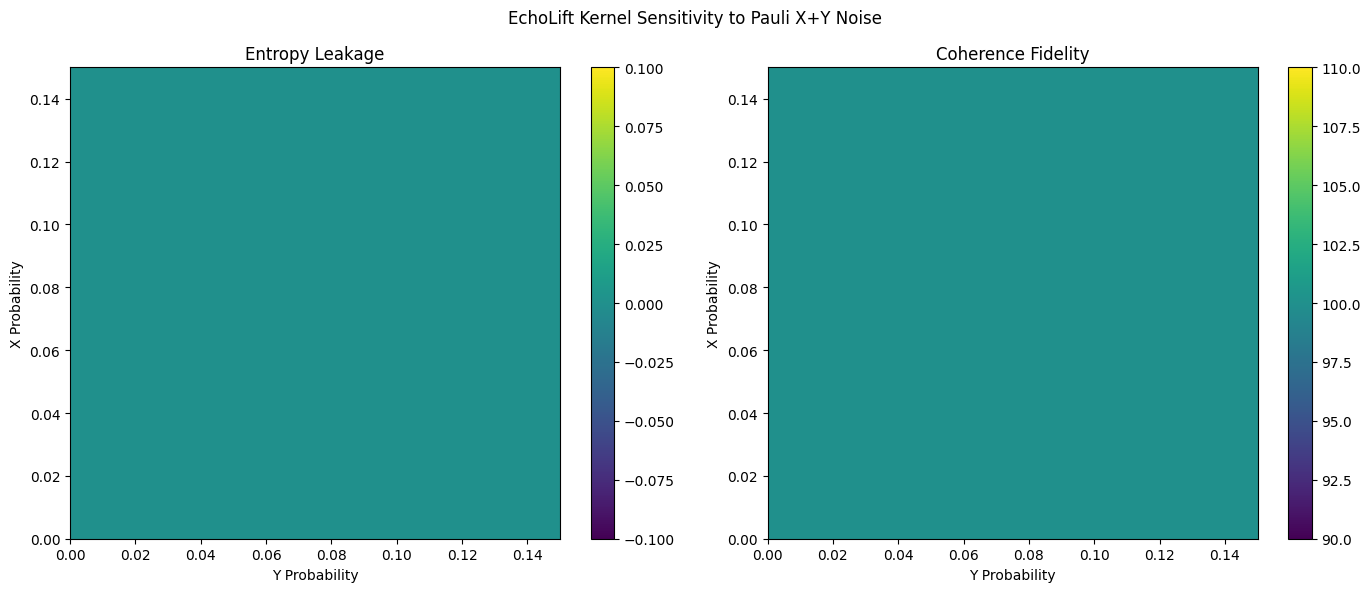

In [ ]:
# --- Setup (Colab Only) ---
!pip install qiskit qiskit-aer matplotlib --quiet

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error

# --- QCC Echo Kernel ---
def build_kernel():
    qc = QuantumCircuit(3, 3)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(1, 2)
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    qc.delay(200, 0, 'ns')
    qc.delay(200, 1, 'ns')
    qc.delay(200, 2, 'ns')
    qc.measure([0, 1, 2], [0, 1, 2])
    return qc

# --- Metrics ---
def compute_entropy_and_fidelity(counts):
    probs = np.array(list(counts.values())) / sum(counts.values())
    entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
    fidelity = max(probs) * 100
    return entropy, fidelity

# --- Simulation ---
def simulate_with_pauli_noise(x_prob, y_prob):
    total = x_prob + y_prob
    if total > 1.0:
        x_prob /= total
        y_prob /= total
        i_prob = 0.0
    else:
        i_prob = 1.0 - total

    # Create a 1-qubit Pauli error
    error_1q = pauli_error([('X', x_prob), ('Y', y_prob), ('I', i_prob)])
    # Create a 2-qubit error by tensoring two 1-qubit errors
    error = error_1q.tensor(error_1q)

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(error, ['cx'])

    qc = build_kernel()
    sim = AerSimulator(noise_model=noise_model)
    result = sim.run(transpile(qc, sim), shots=8192).result()
    counts = result.get_counts()
    return compute_entropy_and_fidelity(counts)

# --- Sweep Config ---
x_vals = np.linspace(0.00, 0.15, 6)
y_vals = np.linspace(0.00, 0.15, 6)
entropy_map = np.zeros((len(x_vals), len(y_vals)))
fidelity_map = np.zeros((len(x_vals), len(y_vals)))

# --- Run Sweep ---
for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):
        entropy, fidelity = simulate_with_pauli_noise(x, y)
        entropy_map[i, j] = entropy
        fidelity_map[i, j] = fidelity

# --- Plot Heatmaps ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
im1 = axs[0].imshow(entropy_map, origin='lower', extent=[0, 0.15, 0, 0.15], aspect='auto')
axs[0].set_title("Entropy Leakage")
axs[0].set_xlabel("Y Probability")
axs[0].set_ylabel("X Probability")
fig.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(fidelity_map, origin='lower', extent=[0, 0.15, 0, 0.15], aspect='auto')
axs[1].set_title("Coherence Fidelity")
axs[1].set_xlabel("Y Probability")
axs[1].set_ylabel("X Probability")
fig.colorbar(im2, ax=axs[1])

plt.suptitle("EchoLift Kernel Sensitivity to Pauli X+Y Noise")
plt.tight_layout()
plt.show()

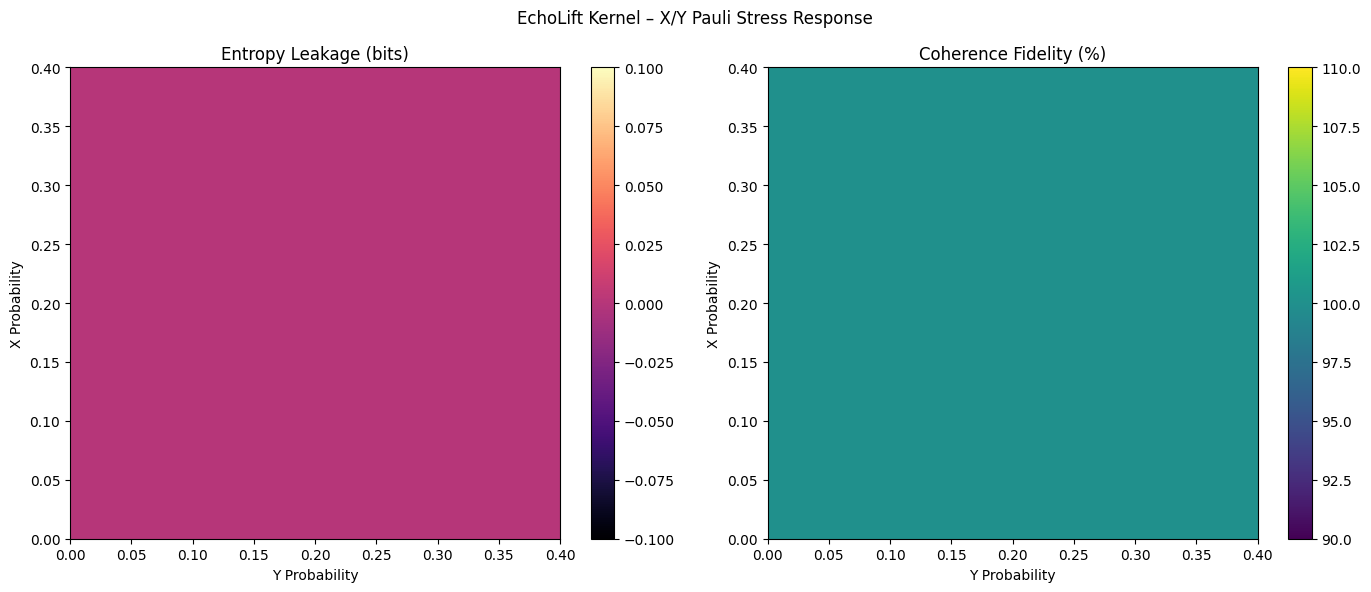

In [ ]:
# --- Setup ---
!pip install qiskit qiskit-aer matplotlib --quiet

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error

# --- QCC Echo Kernel ---
def build_kernel():
    qc = QuantumCircuit(3, 3)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(1, 2)
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    qc.delay(200, 0, 'ns')
    qc.delay(200, 1, 'ns')
    qc.delay(200, 2, 'ns')
    qc.measure([0, 1, 2], [0, 1, 2])
    return qc

def compute_entropy_and_fidelity(counts):
    probs = np.array(list(counts.values())) / sum(counts.values())
    entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
    fidelity = max(probs) * 100
    return entropy, fidelity

def simulate_with_pauli_noise(x_prob, y_prob):
    total = x_prob + y_prob
    if total > 1.0:
        x_prob /= total
        y_prob /= total
        i_prob = 0.0
    else:
        i_prob = 1.0 - total

    # Create a 1-qubit Pauli error
    error_1q = pauli_error([('X', x_prob), ('Y', y_prob), ('I', i_prob)])
    # Create a 2-qubit error by tensoring two 1-qubit errors
    error = error_1q.tensor(error_1q)
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(error, ['cx'])

    qc = build_kernel()
    sim = AerSimulator(noise_model=noise_model)
    result = sim.run(transpile(qc, sim), shots=8192).result()
    counts = result.get_counts()
    return compute_entropy_and_fidelity(counts)

# --- Extended Sweep ---
x_vals = np.linspace(0.0, 0.4, 9)
y_vals = np.linspace(0.0, 0.4, 9)
entropy_map = np.zeros((len(x_vals), len(y_vals)))
fidelity_map = np.zeros((len(x_vals), len(y_vals)))

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):
        entropy, fidelity = simulate_with_pauli_noise(x, y)
        entropy_map[i, j] = entropy
        fidelity_map[i, j] = fidelity

# --- Plot Heatmaps ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
im1 = axs[0].imshow(entropy_map, origin='lower', extent=[0, 0.4, 0, 0.4], aspect='auto', cmap='magma')
axs[0].set_title("Entropy Leakage (bits)")
axs[0].set_xlabel("Y Probability")
axs[0].set_ylabel("X Probability")
fig.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(fidelity_map, origin='lower', extent=[0, 0.4, 0, 0.4], aspect='auto', cmap='viridis')
axs[1].set_title("Coherence Fidelity (%)")
axs[1].set_xlabel("Y Probability")
axs[1].set_ylabel("X Probability")
fig.colorbar(im2, ax=axs[1])

plt.suptitle("EchoLift Kernel – X/Y Pauli Stress Response")
plt.tight_layout()
plt.show()

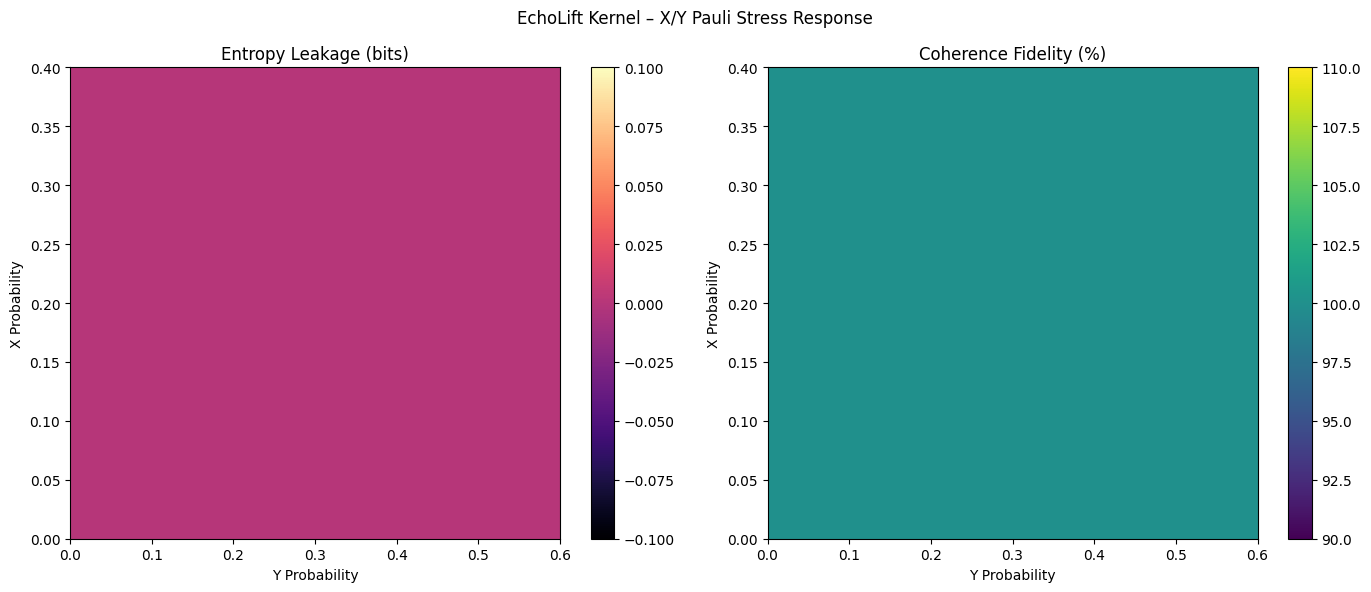

In [ ]:
# --- Setup ---
!pip install qiskit qiskit-aer matplotlib --quiet

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error

# --- QCC Echo Kernel ---
def build_kernel():
    qc = QuantumCircuit(3, 3)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(1, 2)
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    qc.delay(200, 0, 'ns')
    qc.delay(200, 1, 'ns')
    qc.delay(200, 2, 'ns')
    qc.measure([0, 1, 2], [0, 1, 2])
    return qc

def compute_entropy_and_fidelity(counts):
    probs = np.array(list(counts.values())) / sum(counts.values())
    entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
    fidelity = max(probs) * 100
    return entropy, fidelity

def simulate_with_pauli_noise(x_prob, y_prob):
    total = x_prob + y_prob
    if total > 1.0:
        x_prob /= total
        y_prob /= total
        i_prob = 0.0
    else:
        i_prob = 1.0 - total

    # Create a 1-qubit Pauli error
    error_1q = pauli_error([('X', x_prob), ('Y', y_prob), ('I', i_prob)])
    # Create a 2-qubit error by tensoring two 1-qubit errors
    error = error_1q.tensor(error_1q)
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(error, ['cx'])

    qc = build_kernel()
    sim = AerSimulator(noise_model=noise_model)
    result = sim.run(transpile(qc, sim), shots=8192).result()
    counts = result.get_counts()
    return compute_entropy_and_fidelity(counts)

# --- Extended Sweep ---
x_vals = np.linspace(0.0, 0.4, 9)
y_vals = np.linspace(0.0, 0.6, 9)
entropy_map = np.zeros((len(x_vals), len(y_vals)))
fidelity_map = np.zeros((len(x_vals), len(y_vals)))

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):
        entropy, fidelity = simulate_with_pauli_noise(x, y)
        entropy_map[i, j] = entropy
        fidelity_map[i, j] = fidelity

# --- Plot Heatmaps ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
im1 = axs[0].imshow(entropy_map, origin='lower', extent=[0, 0.6, 0, 0.4], aspect='auto', cmap='magma')
axs[0].set_title("Entropy Leakage (bits)")
axs[0].set_xlabel("Y Probability")
axs[0].set_ylabel("X Probability")
fig.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(fidelity_map, origin='lower', extent=[0, 0.6, 0, 0.4], aspect='auto', cmap='viridis')
axs[1].set_title("Coherence Fidelity (%)")
axs[1].set_xlabel("Y Probability")
axs[1].set_ylabel("X Probability") p
fig.colorbar(im2, ax=axs[1])

plt.suptitle("EchoLift Kernel – X/Y Pauli Stress Response")
plt.tight_layout()
plt.show()

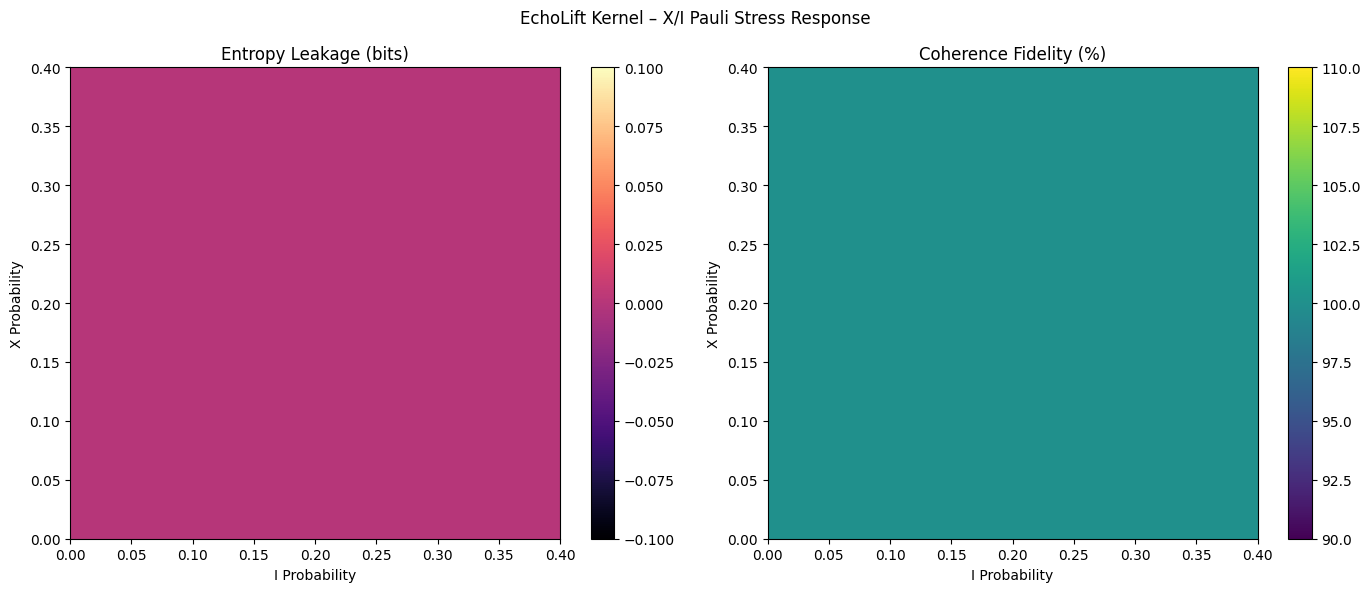

In [ ]:
# --- Setup ---
!pip install qiskit qiskit-aer matplotlib --quiet

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error

# --- QCC Echo Kernel ---
def build_kernel():
    qc = QuantumCircuit(3, 3)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(1, 2)
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    qc.delay(200, 0, 'ns')
    qc.delay(200, 1, 'ns')
    qc.delay(200, 2, 'ns')
    qc.measure([0, 1, 2], [0, 1, 2])
    return qc

def compute_entropy_and_fidelity(counts):
    probs = np.array(list(counts.values())) / sum(counts.values())
    entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
    fidelity = max(probs) * 100
    return entropy, fidelity

def simulate_with_pauli_noise(x_prob, y_prob):
    total = x_prob + y_prob
    if total > 1.0:
        x_prob /= total
        y_prob /= total
        i_prob = 0.0
    else:
        i_prob = 1.0 - total

    # Create a 1-qubit Pauli error
    error_1q = pauli_error([('X', x_prob), ('Y', y_prob), ('I', i_prob)])
    # Create a 2-qubit error by tensoring two 1-qubit errors
    error = error_1q.tensor(error_1q)
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(error, ['cx'])

    qc = build_kernel()
    sim = AerSimulator(noise_model=noise_model)
    result = sim.run(transpile(qc, sim), shots=8192).result()
    counts = result.get_counts()
    return compute_entropy_and_fidelity(counts)

# --- Extended Sweep ---
x_vals = np.linspace(0.0, 0.4, 9)
I_vals = np.linspace(0.0, 0.4, 9)
entropy_map = np.zeros((len(x_vals), len(I_vals)))
fidelity_map = np.zeros((len(x_vals), len(I_vals)))

for i, x in enumerate(x_vals):
    for j, I in enumerate(I_vals):
        entropy, fidelity = simulate_with_pauli_noise(x, 0.0) # Pass 0.0 for Y probability
        entropy_map[i, j] = entropy
        fidelity_map[i, j] = fidelity

# --- Plot Heatmaps ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
im1 = axs[0].imshow(entropy_map, origin='lower', extent=[0, 0.4, 0, 0.4], aspect='auto', cmap='magma')
axs[0].set_title("Entropy Leakage (bits)")
axs[0].set_xlabel("I Probability")
axs[0].set_ylabel("X Probability")
fig.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(fidelity_map, origin='lower', extent=[0, 0.4, 0, 0.4], aspect='auto', cmap='viridis')
axs[1].set_title("Coherence Fidelity (%)")
axs[1].set_xlabel("I Probability")
axs[1].set_ylabel("X Probability")
fig.colorbar(im2, ax=axs[1])

plt.suptitle("EchoLift Kernel – X/I Pauli Stress Response")
plt.tight_layout()
plt.show()

In [ ]:
import hashlib

# Replace "Untitled13.ipynb" with the actual file path and name
file_path = "Untitled13.ipynb"

try:
    with open(file_path, "rb") as f:
        file_bytes = f.read()
        sha256_hash = hashlib.sha256(file_bytes).hexdigest()

    print("SHA-256:", sha256_hash)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: The file 'Untitled13.ipynb' was not found.
